# ScreenSense Analysis

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load CSV from data.csv

In [7]:
df = pd.read_csv('data/raw/data.csv')
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

Loaded 9712 rows and 8 columns


Display First 5 Rows

In [8]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


## Display Last 5 Rows

In [10]:
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


## Dataset Inspection

In [ ]:
# df.shape
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

In [ ]:
# df.info()
df.info()

In [ ]:
# df.describe()
df.describe()

In [ ]:
# df.isnull().sum()
print("Missing Values:")
df.isnull().sum()

In [14]:
# Display all column names
print("Column Names:")
print(df.columns.tolist())
print(f"\nTotal columns: {len(df.columns)}")

Column Names:
['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device', 'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio', 'Health_Impacts', 'Urban_or_Rural']

Total columns: 8


In [18]:
df['screentime_minutes'] = df['Avg_Daily_Screen_Time_hr'] * 60

In [19]:
avg_screentime_by_age = df.groupby('Age')['screentime_minutes'].mean().reset_index()
avg_screentime_by_age.columns = ['Age', 'Average Screen Time (minutes)']

## Column Names

Check what columns are available in the dataset.

## Analysis 1: Average Screen Time by Age

Using groupby() and mean() to calculate average screen time for each age.

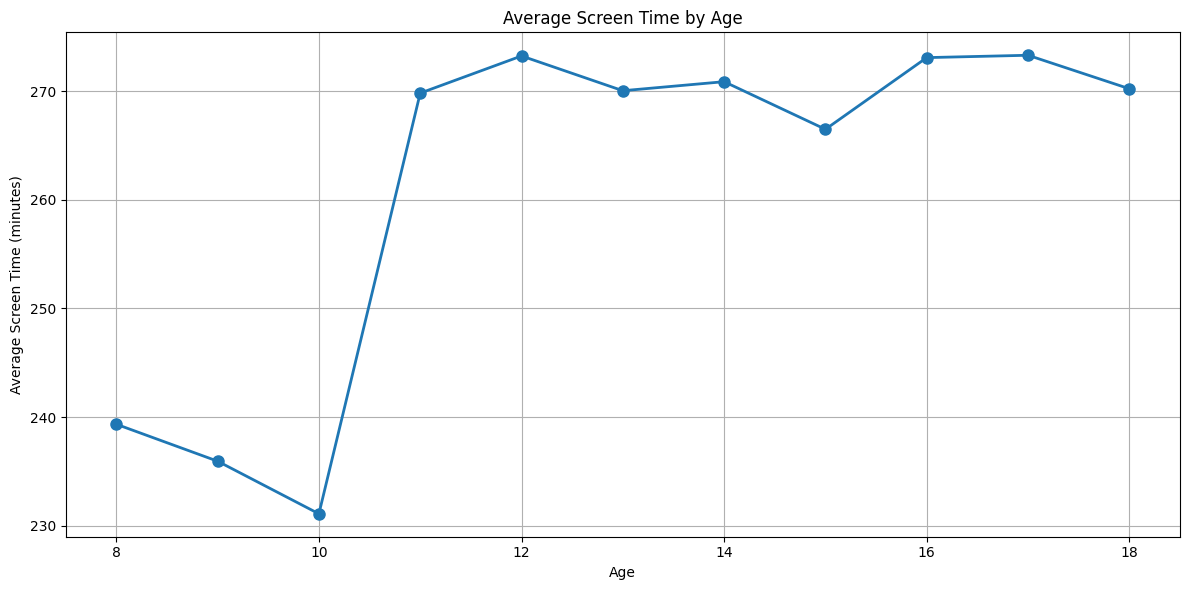

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    avg_screentime_by_age['Age'],
    avg_screentime_by_age['Average Screen Time (minutes)'],
    marker='o',
    linewidth=2,
    markersize=8
)

plt.xlabel('Age')
plt.ylabel('Average Screen Time (minutes)')
plt.title('Average Screen Time by Age')

plt.grid(True)
plt.tight_layout()
plt.show()

## Analysis 2: Average Screen Time by Age Band

Create age bands (3-5, 6-9, 10-13, 14-17) and calculate average screen time.


=== Average Screen Time by Age Band ===
  Age Band  Average Screen Time (minutes)
0      6-9                     237.658765
1    10-13                     261.082330
2    14-17                     270.999156
3      18+                     270.238571


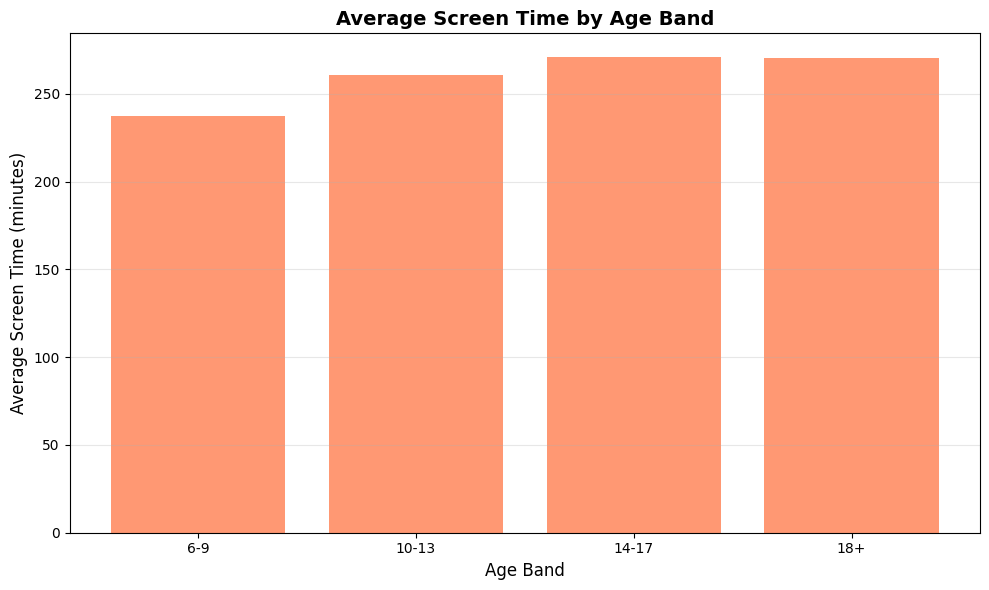

In [21]:
# Create age bands
bins = [0, 5, 9, 13, 17, 100]
labels = ['3-5', '6-9', '10-13', '14-17', '18+']
df['age_band'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Average screen time by age band
avg_screentime_by_band = df.groupby('age_band')['screentime_minutes'].mean().reset_index()
avg_screentime_by_band.columns = ['Age Band', 'Average Screen Time (minutes)']

print("\n=== Average Screen Time by Age Band ===")
print(avg_screentime_by_band)

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(avg_screentime_by_band['Age Band'], avg_screentime_by_band['Average Screen Time (minutes)'], 
        color='coral', alpha=0.8)
plt.xlabel('Age Band', fontsize=12)
plt.ylabel('Average Screen Time (minutes)', fontsize=12)
plt.title('Average Screen Time by Age Band', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Analysis 3: Comparison of Average Screen Time by Gender

Using groupby() to compare screen time patterns between genders.


=== Average Screen Time by Gender ===
   Gender  Mean (minutes)  Median (minutes)     Std Dev  Count
0  Female      259.621258             265.2  104.651325   4770
1    Male      262.665237             267.0  101.556319   4942


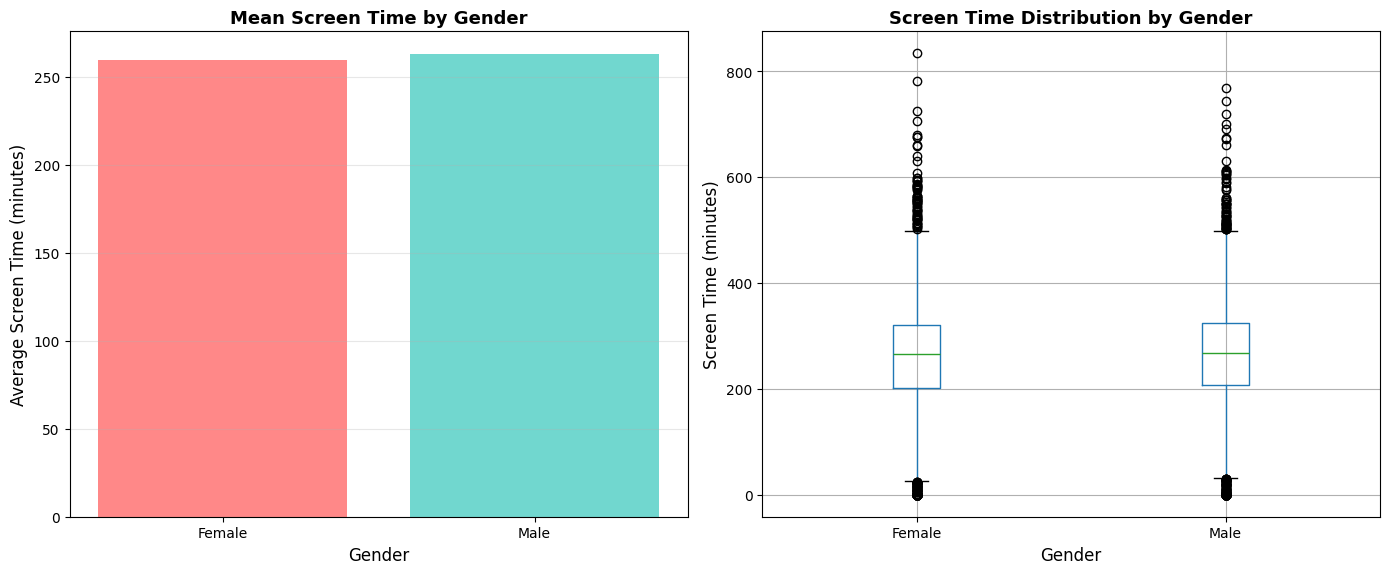

In [22]:
# Average screen time by gender using groupby
avg_screentime_by_gender = df.groupby('Gender')['screentime_minutes'].agg(['mean', 'median', 'std', 'count']).reset_index()
avg_screentime_by_gender.columns = ['Gender', 'Mean (minutes)', 'Median (minutes)', 'Std Dev', 'Count']

print("\n=== Average Screen Time by Gender ===")
print(avg_screentime_by_gender)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].bar(avg_screentime_by_gender['Gender'], avg_screentime_by_gender['Mean (minutes)'], 
            color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Average Screen Time (minutes)', fontsize=12)
axes[0].set_title('Mean Screen Time by Gender', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot for distribution comparison
df.boxplot(column='screentime_minutes', by='Gender', ax=axes[1])
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Screen Time (minutes)', fontsize=12)
axes[1].set_title('Screen Time Distribution by Gender', fontsize=13, fontweight='bold')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

## Analysis 4: Distribution of Main Devices

Analyze the distribution of different device types used.


=== Distribution of Primary Devices ===
       Device  Count
0  Smartphone   4568
1          TV   2487
2      Laptop   1433
3      Tablet   1224

Total devices: 9712


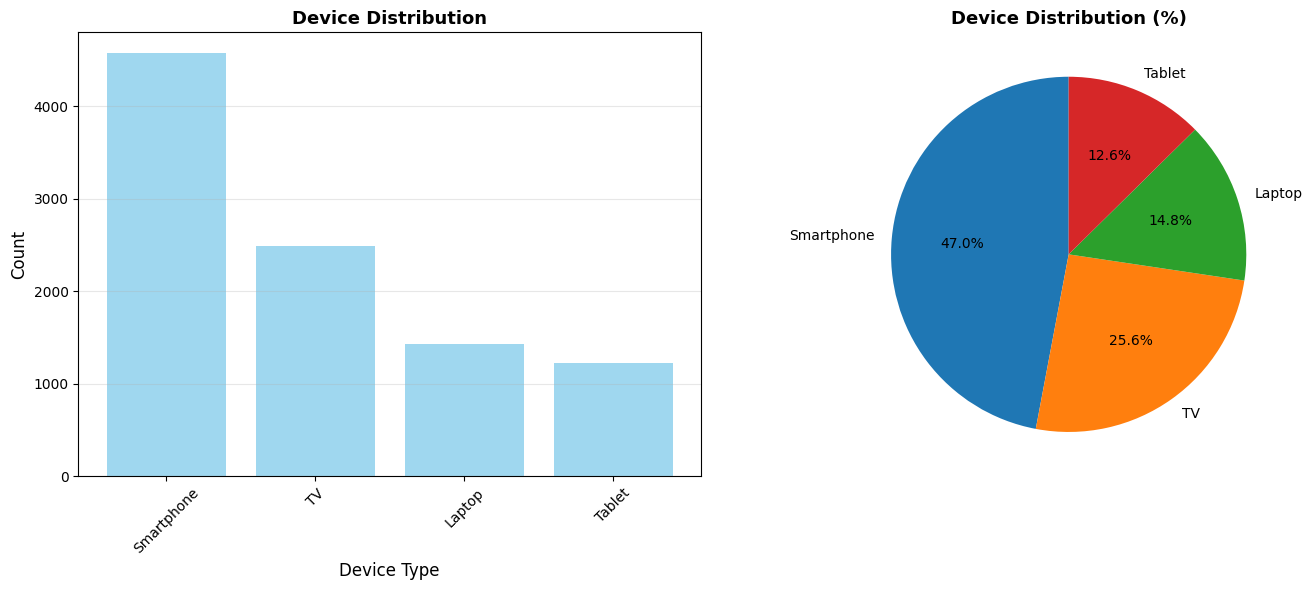

In [23]:
# Distribution of primary devices
device_counts = df['Primary_Device'].value_counts().reset_index()
device_counts.columns = ['Device', 'Count']

print("\n=== Distribution of Primary Devices ===")
print(device_counts)
print(f"\nTotal devices: {device_counts['Count'].sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].bar(device_counts['Device'], device_counts['Count'], color='skyblue', alpha=0.8)
axes[0].set_xlabel('Device Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Device Distribution', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(device_counts['Count'], labels=device_counts['Device'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Device Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Analysis 5: Device Based Analysis

Analyze screen time patterns across different devices.

In [ ]:
# Device based analysis - Average screen time by device
device_analysis = df.groupby('Primary_Device')['screentime_minutes'].agg(['mean', 'median', 'min', 'max', 'count']).reset_index()
device_analysis.columns = ['Device', 'Mean (min)', 'Median (min)', 'Min (min)', 'Max (min)', 'Count']

print("\n=== Screen Time by Device Type ===")
print(device_analysis)

# Visualize average screen time by device
plt.figure(figsize=(12, 6))
plt.bar(device_analysis['Device'], device_analysis['Mean (min)'], color='mediumseagreen', alpha=0.8)
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Average Screen Time (minutes)', fontsize=12)
plt.title('Average Screen Time by Device Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-analysis: Device usage by age band
device_age_analysis = df.groupby(['age_band', 'Primary_Device'])['screentime_minutes'].mean().reset_index()
device_age_pivot = device_age_analysis.pivot(index='age_band', columns='Primary_Device', values='screentime_minutes')

print("\n=== Average Screen Time by Age Band and Device ===")
print(device_age_pivot)

# Visualize
device_age_pivot.plot(kind='bar', figsize=(12, 6), alpha=0.8)
plt.xlabel('Age Band', fontsize=12)
plt.ylabel('Average Screen Time (minutes)', fontsize=12)
plt.title('Average Screen Time by Age Band and Device Type', fontsize=14, fontweight='bold')
plt.legend(title='Device Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()